In [10]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 200

Student_ID     = list(range(1, n+1))
Study_Hours    = np.round(np.random.uniform(1, 10, n), 1)
Attendance     = np.random.randint(50, 100, n)
Previous_Marks = np.random.randint(30, 100, n)
Assignments    = np.random.randint(40, 100, n)
Internal_Marks = np.random.randint(30, 100, n)

# Balanced Pass/Fail logic
Final_Result = []
for i in range(n):
    avg = (
        Study_Hours[i] * 10 +
        Attendance[i] +
        Previous_Marks[i] +
        Assignments[i] +
        Internal_Marks[i]
    ) / 5
    Final_Result.append('Pass' if avg >= 65 else 'Fail')

df = pd.DataFrame({
    'Student_ID':     Student_ID,
    'Study_Hours':    Study_Hours,
    'Attendance':     Attendance,
    'Previous_Marks': Previous_Marks,
    'Assignments':    Assignments,
    'Internal_Marks': Internal_Marks,
    'Final_Result':   Final_Result
})

df.to_csv('student_data.csv', index=False)

print("✅ Dataset created and saved inside Colab!")
print(f"Rows: {len(df)} | Columns: {len(df.columns)}")
print(list(df.columns))
print(f"\nPass: {df['Final_Result'].value_counts()['Pass']} | Fail: {df['Final_Result'].value_counts()['Fail']}")
print(df.head(10).to_string(index=False))

✅ Dataset created and saved inside Colab!
Rows: 200 | Columns: 7
['Student_ID', 'Study_Hours', 'Attendance', 'Previous_Marks', 'Assignments', 'Internal_Marks', 'Final_Result']

Pass: 99 | Fail: 101
 Student_ID  Study_Hours  Attendance  Previous_Marks  Assignments  Internal_Marks Final_Result
          1          4.4          73              45           64              55         Fail
          2          9.6          60              77           61              43         Pass
          3          7.6          98              68           98              88         Pass
          4          6.4          57              62           66              85         Pass
          5          2.4          85              52           88              36         Fail
          6          2.4          87              39           52              32         Fail
          7          1.5          89              98           72              52         Pass
          8          8.8          69      

In [ ]:
import pandas as pd

# Load the CSV 
df = pd.read_csv('student_data.csv')

print("✅ Dataset loaded successfully!")
print(f"\nShape: {df.shape}  →  {df.shape[0]} rows, {df.shape[1]} columns")
print("\nColumn Names:")
print(list(df.columns))
print("\nFirst 5 rows:")
print(df.head())
print("\nPass/Fail Count:")
print(df['Final_Result'].value_counts())

✅ Dataset loaded successfully!

Shape: (200, 7)  →  200 rows, 7 columns

Column Names:
['Student_ID', 'Study_Hours', 'Attendance', 'Previous_Marks', 'Assignments', 'Internal_Marks', 'Final_Result']

First 5 rows:
   Student_ID  Study_Hours  Attendance  Previous_Marks  Assignments  \
0           1          4.4          73              45           64   
1           2          9.6          60              77           61   
2           3          7.6          98              68           98   
3           4          6.4          57              62           66   
4           5          2.4          85              52           88   

   Internal_Marks Final_Result  
0              55         Fail  
1              43         Pass  
2              88         Pass  
3              85         Pass  
4              36         Fail  

Pass/Fail Count:
Final_Result
Fail    101
Pass     99
Name: count, dtype: int64


/tmp/ipykernel_11975/3515325659.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Final_Result', y='Study_Hours', data=df, palette='Set2')


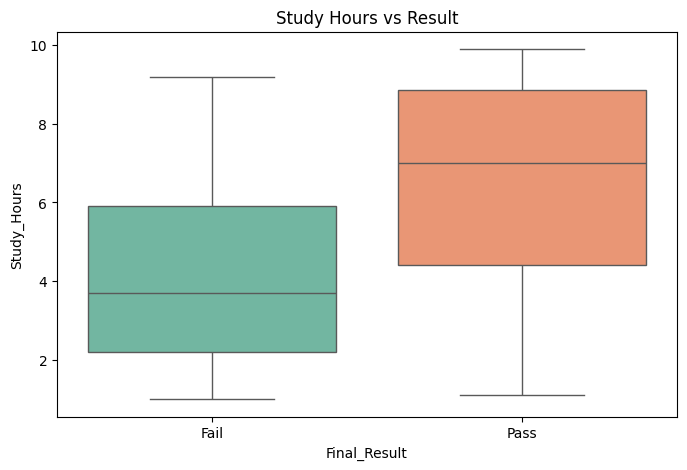

/tmp/ipykernel_11975/3515325659.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Final_Result', y='Attendance', data=df, palette='Set1')


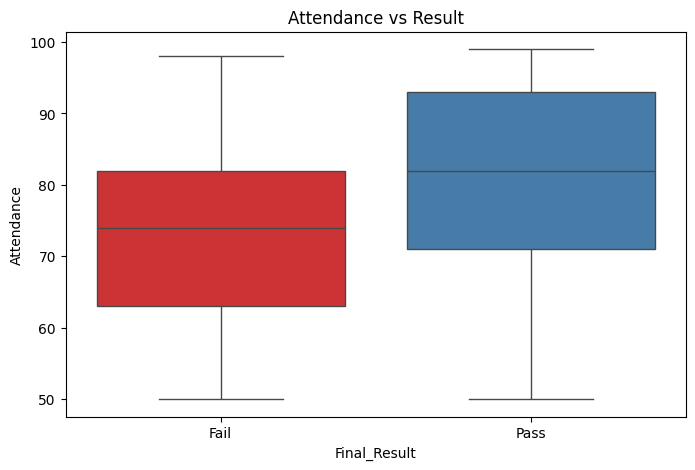

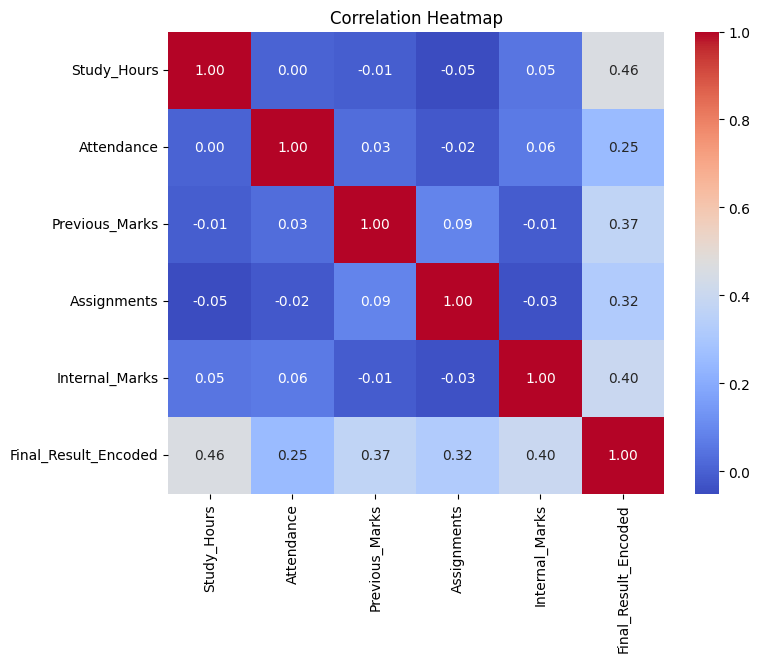

✅ EDA Done!


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Encode Pass=1, Fail=0
le = LabelEncoder()
df['Final_Result_Encoded'] = le.fit_transform(df['Final_Result'])

# Graph 1
plt.figure(figsize=(8,5))
sns.boxplot(x='Final_Result', y='Study_Hours', data=df, palette='Set2')
plt.title('Study Hours vs Result')
plt.show()

# Graph 2
plt.figure(figsize=(8,5))
sns.boxplot(x='Final_Result', y='Attendance', data=df, palette='Set1')
plt.title('Attendance vs Result')
plt.show()

# Graph 3
plt.figure(figsize=(8,6))
cols = ['Study_Hours','Attendance','Previous_Marks','Assignments','Internal_Marks','Final_Result_Encoded']
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

print("✅ EDA Done!")

Class distribution:
Final_Result_Encoded
0    101
1     99
Name: count, dtype: int64
0 = Fail, 1 = Pass

Train size: 160 | Test size: 40

=== MODEL ACCURACY COMPARISON ===

Logistic Regression       → 100.00%
Decision Tree             → 72.50%
Naive Bayes               → 97.50%
SVM                       → 80.00%


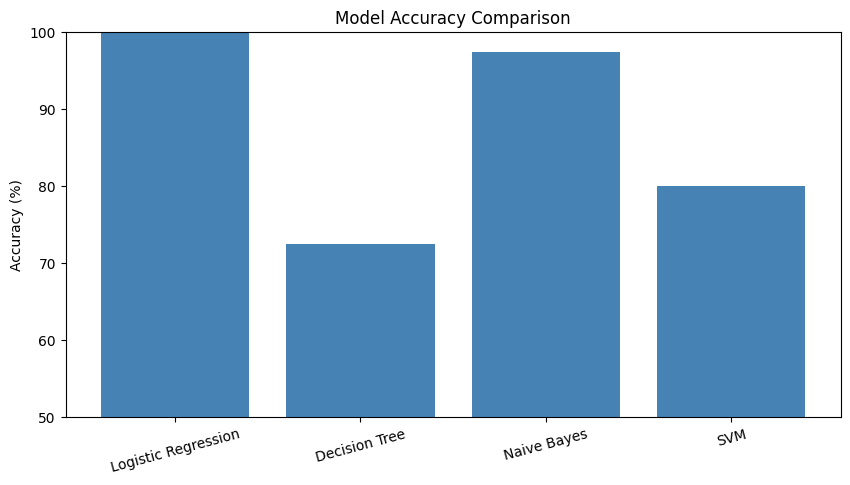


✅ All models trained!


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Encode Pass=1, Fail=0
le = LabelEncoder()
df['Final_Result_Encoded'] = le.fit_transform(df['Final_Result'])

print("Class distribution:")
print(df['Final_Result_Encoded'].value_counts())
print("0 = Fail, 1 = Pass")

X = df[['Study_Hours','Attendance','Previous_Marks','Assignments','Internal_Marks']]
y = df['Final_Result_Encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTrain size: {len(X_train)} | Test size: {len(X_test)}")

# models 
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree':       DecisionTreeClassifier(),
    'Naive Bayes':         GaussianNB(),
    'SVM':                 SVC()
}

print("\n=== MODEL ACCURACY COMPARISON ===\n")
results_dict = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    results_dict[name] = acc
    print(f"{name:25s} → {acc*100:.2f}%")

plt.figure(figsize=(10,5))
plt.bar(results_dict.keys(), [v*100 for v in results_dict.values()], color='steelblue')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(50, 100)
plt.xticks(rotation=15)
plt.show()

print("\n✅ All models trained!")

=== LOGISTIC REGRESSION - FULL REPORT ===

              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00        16
        Pass       1.00      1.00      1.00        24

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



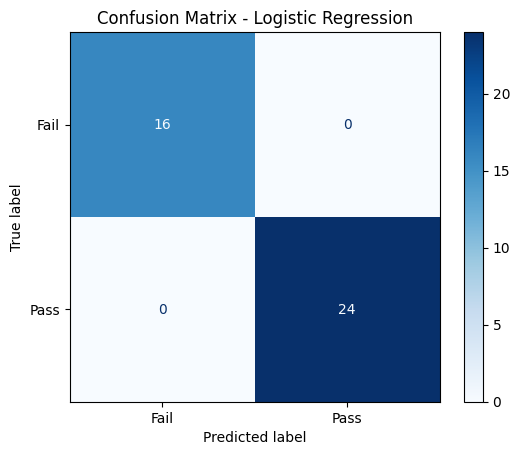

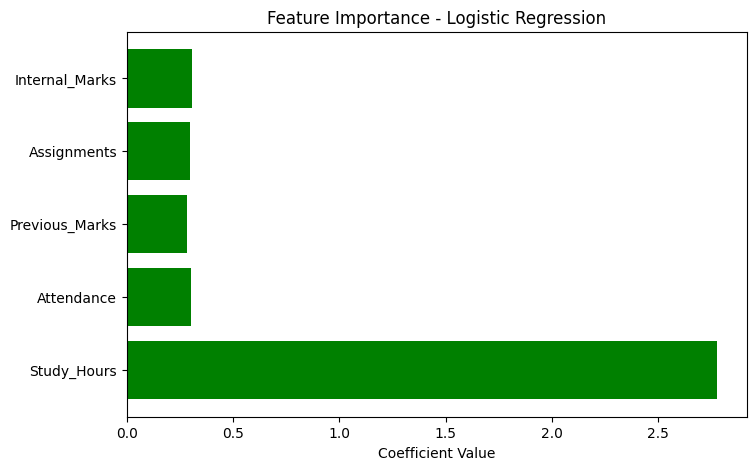

✅ Evaluation Done!


In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

# Best model = Logistic Regression (highest accuracy)
best_model = LogisticRegression(max_iter=1000)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("=== LOGISTIC REGRESSION - FULL REPORT ===\n")
print(classification_report(y_test, y_pred, target_names=['Fail','Pass']))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Fail','Pass']).plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# Coefficient importance 
import numpy as np
coefficients = np.abs(best_model.coef_[0])
feature_names = ['Study_Hours','Attendance','Previous_Marks','Assignments','Internal_Marks']

plt.figure(figsize=(8,5))
plt.barh(feature_names, coefficients, color='green')
plt.title('Feature Importance - Logistic Regression')
plt.xlabel('Coefficient Value')
plt.show()

print("✅ Evaluation Done!")

In [15]:
new_students = pd.DataFrame({
    'Study_Hours':    [8.5, 2.0, 5.0],
    'Attendance':     [90,  55,  70],
    'Previous_Marks': [85,  35,  60],
    'Assignments':    [90,  40,  65],
    'Internal_Marks': [88,  30,  55]
})

preds = best_model.predict(new_students)
new_students['Predicted_Result'] = ['Pass' if p==1 else 'Fail' for p in preds]

print("=== NEW STUDENT PREDICTIONS ===\n")
print(new_students.to_string(index=False))

print("\n⚠️ AT-RISK STUDENTS (Predicted FAIL):")
print(new_students[new_students['Predicted_Result']=='Fail'].to_string(index=False))

print("\n✅ PROJECT COMPLETE!")

=== NEW STUDENT PREDICTIONS ===

 Study_Hours  Attendance  Previous_Marks  Assignments  Internal_Marks Predicted_Result
         8.5          90              85           90              88             Pass
         2.0          55              35           40              30             Fail
         5.0          70              60           65              55             Fail

⚠️ AT-RISK STUDENTS (Predicted FAIL):
 Study_Hours  Attendance  Previous_Marks  Assignments  Internal_Marks Predicted_Result
         2.0          55              35           40              30             Fail
         5.0          70              60           65              55             Fail

✅ PROJECT COMPLETE!
